# Proyek Klasifikasi Gambar: [fresh-and-stale-classification]

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip -q install kagglehub tensorflowjs==4.20.0

import os, shutil, random, pathlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

print("TensorFlow: ", tf.__version__)
tf.keras.utils.set_random_seed(42)
random.seed(42)
np.random.seed(42)

# Download dataset Fruit Fresh and Rotten Classification
import kagglehub
# Download latest version
path = kagglehub.dataset_download("swoyam2609/fresh-and-stale-classification")
print("Path to dataset files:", path)




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
TensorFlow:  2.19.0


100%|██████████| 2.84G/2.84G [00:29<00:00, 102MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/swoyam2609/fresh-and-stale-classification/versions/1


## Data Preparation

### Data Loading

In [16]:
# gabungkan train & test awal agar dapat di split sendiri
original_train = os.path.join(path, "dataset", "Train")
original_test = os.path.join(path, "dataset", "Test")

base_dir = "/content/fresh_rotten_selfsplit"
all_dir = os.path.join(base_dir, "all")

if os.path.exists(all_dir):
    shutil.rmtree(all_dir)

os.makedirs(all_dir, exist_ok=True)

allowed_classes = ['freshapples', 'rottenapples', 'freshbanana', 'rottenbanana', 'freshoranges', 'rottenoranges']

def copy_tree(src):
  if not os.path.exists(src):
    print(f"Direktori {src} tidak ditemukan!")
    return

  for cls in os.listdir(src):
    if cls not in allowed_classes:
      continue

    scls = os.path.join(src, cls)
    if not os.path.isdir(scls):
        continue

    dcls = os.path.join(all_dir, cls)
    os.makedirs(dcls, exist_ok=True)

    for f in os.listdir(scls):
        shutil.copy(os.path.join(scls, f), os.path.join(dcls, f))

print("Proses menyalin gambar dimulai. Mohon tunggu sebentar...")

copy_tree(original_train)
copy_tree(original_test)

print("Semua gambar berhasil digabung di:", all_dir)
print("Total kelas yang ditemukan:", os.listdir(all_dir))

Proses menyalin gambar dimulai. Mohon tunggu sebentar...
Semua gambar berhasil digabung di: /content/fresh_rotten_selfsplit/all
Total kelas yang ditemukan: ['freshoranges', 'freshapples', 'freshbanana', 'rottenoranges', 'rottenbanana', 'rottenapples']


### Data Preprocessing

#### Split Dataset

In [17]:
# Split Dataset menjadi : 70% train, 20% validation, 10% test
from sklearn.model_selection import train_test_split

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
  shutil.rmtree(d, ignore_errors=True)
  for cls in os.listdir(all_dir):
    os.makedirs(os.path.join(d, cls), exist_ok=True)

# ambil semua file & dataset
image_paths, labels = [], []
for cls in os.listdir(all_dir):
  for f in os.listdir(os.path.join(all_dir, cls)):
    image_paths.append(os.path.join(all_dir, cls, f))
    labels.append(cls)

X = np.array(image_paths)
y = np.array(labels)

# split berlapis
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42)

def move_files(X, y, target_dir):
  for p, lbl in zip(X, y):
    shutil.copy(p, os.path.join(target_dir, lbl, os.path.basename(p)))

move_files(X_train, y_train, train_dir)
move_files(X_val, y_val, val_dir)
move_files(X_test, y_test, test_dir)

print("Dataset berhasil dibagi!")

Dataset berhasil dibagi!


## Modelling

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (150, 150)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    rotation_range = 20,
    zoom_range = 0.15,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical')
test_gen = test_datagen.flow_from_directory(test_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical')

model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2, 2),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.BatchNormalization(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(train_gen, validation_data=val_gen, epochs=25, callbacks=callbacks)
test_loss, test_acc = model.evaluate(test_gen)
print(f"Akurasi data test: {test_acc*100:.2f}%")

Found 11781 images belonging to 6 classes.
Found 3383 images belonging to 6 classes.
Found 1667 images belonging to 6 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 131s 339ms/step - accuracy: 0.6437 - loss: 1.8979 - val_accuracy: 0.6429 - val_loss: 1.0111 - learning_rate: 5.0000e-04
Epoch 2/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 116s 315ms/step - accuracy: 0.7923 - loss: 0.7767 - val_accuracy: 0.8413 - val_loss: 0.4271 - learning_rate: 5.0000e-04
Epoch 3/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 115s 311ms/step - accuracy: 0.8297 - loss: 0.5454 - val_accuracy: 0.2660 - val_loss: 9.3224 - learning_rate: 5.0000e-04
Epoch 4/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 116s 313ms/step - accuracy: 0.8452 - loss: 0.5485 - val_accuracy: 0.7224 - val_loss: 0.9482 - learning_rate: 5.0000e-04
Epoch 5/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 114s 310ms/step - accuracy: 0.8460 - loss: 0.4964 - val_accuracy: 0.9033 - val_loss: 0.3514 - learning_rate: 5.0000e-04
Epoch 6/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 113s 308ms/step - accuracy: 0.8697 - loss: 0.4373 - val_accuracy: 0.9211 - val_loss: 0.2149 - learning_rate: 5.0000e-04
Epoch 7/25
369/369 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluasi dan Visualisasi

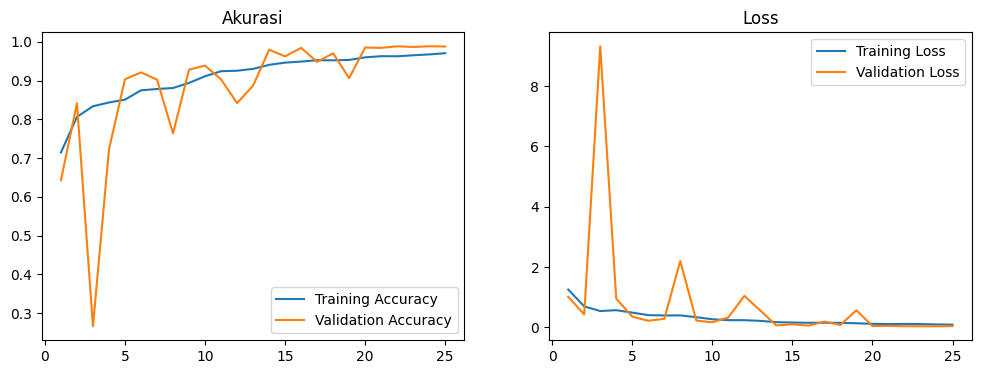

In [19]:
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend(); plt.title('Akurasi')
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend(); plt.title('Loss')
plt.show()

## Konversi Model

In [20]:
import tensorflowjs as tfjs

os.makedirs("model", exist_ok=True)

# format Savedmodel
model.export("model/saved_model")
print("Model berhasil disimpan!")

# format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model/model.tflite", "wb") as f:
  f.write(tflite_model)
print("Model TFLite tersimpan.")

# format TFJS
os.makedirs("model/tfjs_model", exist_ok=True)
tfjs.converters.save_keras_model(model, "model/tfjs_model")
print("Model TFJS tersimpan.")


Saved artifact at 'model/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  138940758382096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940810392400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940758383440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940758385360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940758385168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940758384784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940758386512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940763106640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940763100688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138940763107984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1389407631

Model TFLite tersimpan.
failed to lookup keras version from the file,
    this is likely a weight only file
Model TFJS tersimpan.


## Inference (Optional)

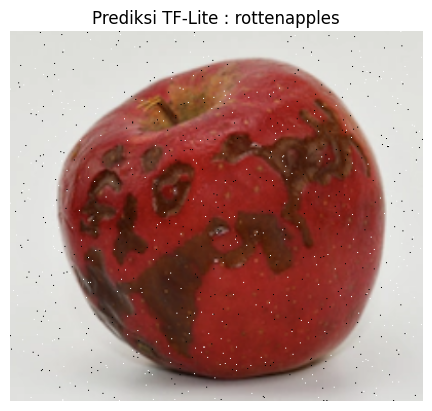

Hasil Prediksi label:  rottenapples


In [27]:
from tensorflow.keras.preprocessing import image


interpreter = tf.lite.Interpreter(model_path="model/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

kelas_sample = os.listdir(test_dir)[5]
gambar_sample = os.listdir(os.path.join(test_dir, kelas_sample))[0]
sample_image_path = os.path.join(test_dir, kelas_sample, gambar_sample)

img = image.load_img(sample_image_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], img_array)
interpreter.invoke()
prediction = interpreter.get_tensor(output_details[0]['index'])

class_idx = np.argmax(prediction)
label = list(train_gen.class_indices.keys())[class_idx]

plt.imshow(image.load_img(sample_image_path))
plt.title(f"Prediksi TF-Lite : {label}")
plt.axis("off")
plt.show()
print("Hasil Prediksi label: ", label)